# Analysis 4: Orbital Period Valley by Planet Size

**Author:** Aradhya Haldikar  
**Date:** March 2026  
**Corresponding paper:** *A Self‑Directed Census: Analyzing 6,105 Confirmed Exoplanets from First Principles*  
**GitHub repository:** [https://github.com/Dhpla12/exoplanet-analysis](https://github.com/Dhpla12/exoplanet-analysis)

---

## About this analysis

This notebook reproduces **Section 3.8** of the paper. It examines how the "period valley"—a deficit of giant planets at intermediate orbital periods—manifests differently for planets of different sizes.

### Goals:
- Fetch confirmed exoplanet data with orbital periods.
- Apply a 30% radius uncertainty cut.
- Classify planets into three size bins: super‑Earths (<2 R⊕), sub‑Neptunes (2–4 R⊕), and giants (>4 R⊕).
- Plot period histograms (0–100 days and 0–500 days) for each class.
- Count planets in the canonical valley region (10–30 days).

### Data source:
- **Original data:** NASA Exoplanet Archive Planetary Systems Table (`ps`), DOI: [10.26133/NEA13](https://doi.org/10.26133/NEA13)
- **Filtered dataset:** Harvard Dataverse, DOI: [10.7910/DVN/WQGSNE](https://doi.org/10.7910/DVN/WQGSNE)

### Key result:
Giants avoid the 10–30 day region (only 12.5% reside there), while sub‑Neptunes actually peak in this interval (40.9%). Super‑Earths are intermediate (23.2%). This reveals a size‑dependent orbital architecture.

---

## How to use this notebook

1. Run all cells sequentially.
2. Two period histograms will be displayed.
3. The final cell prints the number and percentage of planets in the 10–30 day valley for each size class.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.4 MB/s eta 0:00:00
Fetching confirmed planets data with orbital period...
Total confirmed planets: 6128
Columns: ['pl_name', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_orbper', 'discoverymethod']

Planets with radius quality and period: 3686

Counts by size class:
size_class
Sub-Neptune (2–4 R⊕)    1339
Super-Earth (<2 R⊕)     1299
Giant (>4 R⊕)           1048
Name: count, dtype: int64


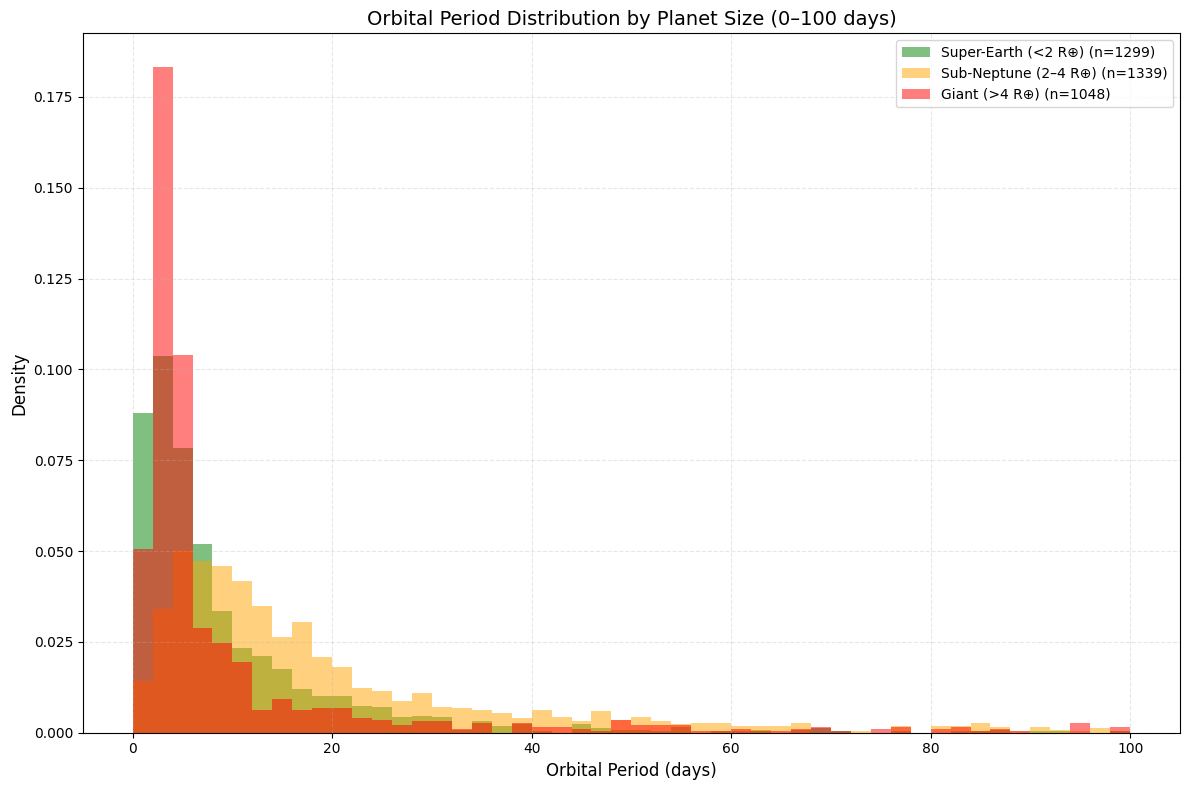

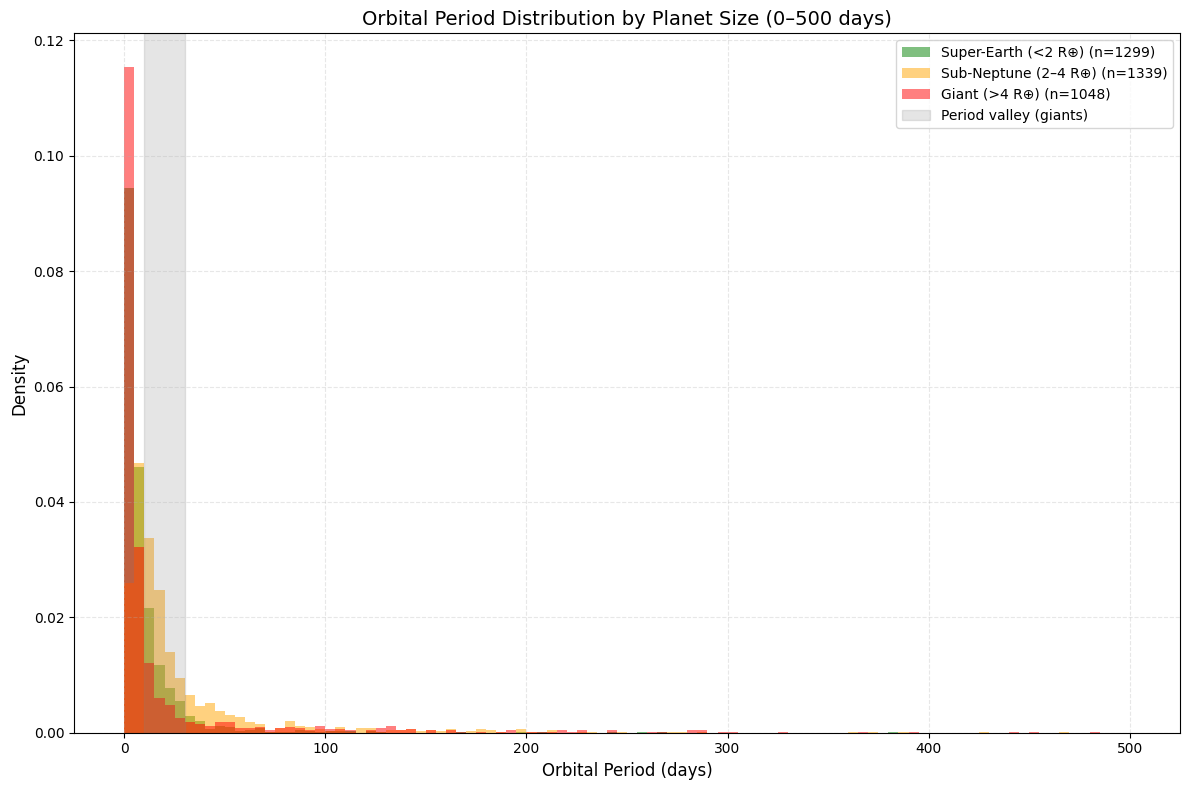


PLANETS IN THE PERIOD VALLEY (10–30 days)
Super-Earth (<2 R⊕): 302 planets (23.2% of 1299)
Sub-Neptune (2–4 R⊕): 547 planets (40.9% of 1339)
Giant (>4 R⊕): 131 planets (12.5% of 1048)


In [2]:
# =============================================================================
# Analysis 4: Orbital Period Valley by Planet Size
# =============================================================================

# Install astroquery
!pip install astroquery --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# 1. Fetch data with orbital period
print("Fetching confirmed planets data with orbital period...")
df4 = NasaExoplanetArchive.query_criteria(
    table="ps",
    select="pl_name, pl_rade, pl_radeerr1, pl_radeerr2, pl_orbper, discoverymethod",
    where="default_flag=1",
    cache=False
).to_pandas()

print(f"Total confirmed planets: {len(df4)}")
print(f"Columns: {df4.columns.tolist()}\n")

# 2. Apply radius quality cut
rade_ok = df4['pl_rade'].notna() & df4['pl_radeerr1'].notna() & df4['pl_radeerr2'].notna()
df4['rade_frac_err'] = np.nan
df4.loc[rade_ok, 'rade_frac_err'] = np.maximum(df4.loc[rade_ok, 'pl_radeerr1'], df4.loc[rade_ok, 'pl_radeerr2']) / df4.loc[rade_ok, 'pl_rade']
df4['rade_quality'] = df4['rade_frac_err'] < 0.3

# Also need period
has_period = df4['pl_orbper'].notna()
good_for_period = df4['rade_quality'] & has_period
df_period = df4[good_for_period].copy()

print(f"Planets with radius quality and period: {len(df_period)}")

# 3. Classify by size (same as before)
def size_class(radius):
    if radius < 2:
        return 'Super-Earth (<2 R⊕)'
    elif radius < 4:
        return 'Sub-Neptune (2–4 R⊕)'
    else:
        return 'Giant (>4 R⊕)'

df_period['size_class'] = df_period['pl_rade'].apply(size_class)

print("\nCounts by size class:")
print(df_period['size_class'].value_counts())

# 4. Plot period histograms
plt.figure(figsize=(12, 8))
classes = ['Super-Earth (<2 R⊕)', 'Sub-Neptune (2–4 R⊕)', 'Giant (>4 R⊕)']
colors = ['green', 'orange', 'red']

for i, (size, color) in enumerate(zip(classes, colors)):
    subset = df_period[df_period['size_class'] == size]
    plt.hist(subset['pl_orbper'], bins=50, range=(0, 100), alpha=0.5,
             color=color, label=f"{size} (n={len(subset)})", density=True)

plt.xlabel('Orbital Period (days)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Orbital Period Distribution by Planet Size (0–100 days)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Look for the "period valley" (around 10–30 days for giants)
plt.figure(figsize=(12, 8))
for i, (size, color) in enumerate(zip(classes, colors)):
    subset = df_period[df_period['size_class'] == size]
    plt.hist(subset['pl_orbper'], bins=100, range=(0, 500), alpha=0.5,
             color=color, label=f"{size} (n={len(subset)})", density=True)

plt.axvspan(10, 30, alpha=0.2, color='gray', label='Period valley (giants)')
plt.xlabel('Orbital Period (days)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Orbital Period Distribution by Planet Size (0–500 days)', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Print statistics for the valley region
valley_min = 10
valley_max = 30

print("\n" + "="*60)
print("PLANETS IN THE PERIOD VALLEY (10–30 days)")
print("="*60)
for size in classes:
    subset = df_period[(df_period['size_class'] == size) &
                       (df_period['pl_orbper'] >= valley_min) &
                       (df_period['pl_orbper'] <= valley_max)]
    total = len(df_period[df_period['size_class'] == size])
    fraction = len(subset) / total if total > 0 else 0
    print(f"{size}: {len(subset)} planets ({fraction*100:.1f}% of {total})")

### Accounting for Transit Survey Detection Biases

The observed period distributions are influenced by the sensitivity of transit surveys. Planets with larger radii and shorter periods are easier to detect. To assess whether the difference between giants and sub‑Neptunes in the 10–30 day valley could arise from these biases, we apply a simple detection efficiency correction.

We model the relative detection efficiency as a product of a geometric factor (transit probability $\propto P^{-2/3}$) and a signal‑to‑noise factor (transit depth $\propto R^2$). This yields an approximate weight $w \propto R^2 P^{-2/3}$. For each planet, we compute this weight, then construct bias‑corrected histograms by weighting each planet by $1/w$ (normalized so that the mean weight in each size class is unity). This correction is approximate but serves to test whether the observed valley fractions could be explained solely by survey sensitivity.

/tmp/ipykernel_499/652926883.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  giants['weight'] = detection_efficiency(giants['pl_rade'], giants['pl_orbper'])
/tmp/ipykernel_499/652926883.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subneps['weight'] = detection_efficiency(subneps['pl_rade'], subneps['pl_orbper'])
/tmp/ipykernel_499/652926883.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead




Giants:
  Observed fraction in valley: 12.5%
  Bias‑corrected fraction: 2.5%

Sub‑Neptunes:
  Observed fraction in valley: 40.9%
  Bias‑corrected fraction: 29.8%


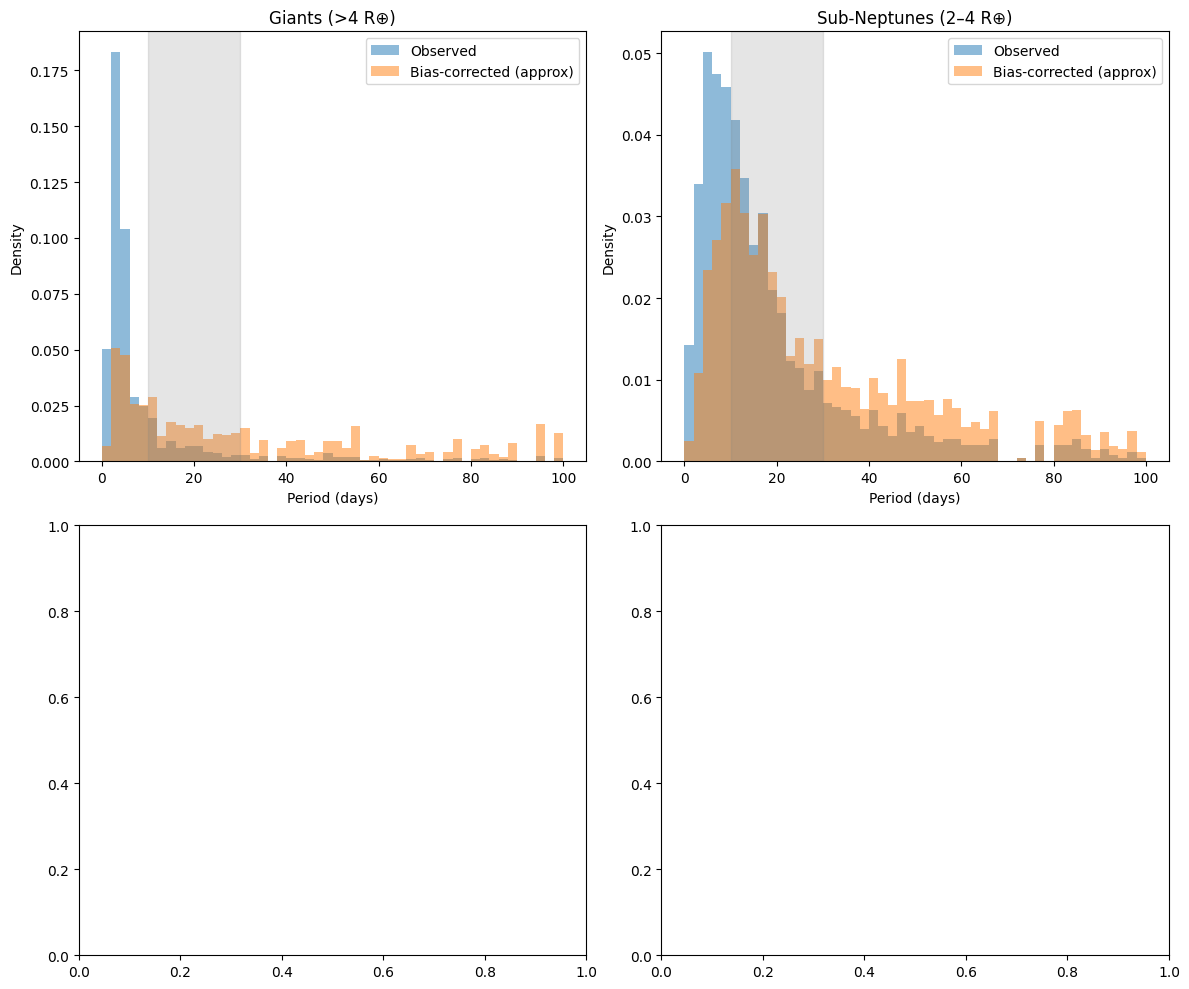

In [5]:
# ===== DETECTION EFFICIENCY TEST FOR PERIOD VALLEY =====
# Approximate transit survey sensitivity as function of period and radius
# Based on Kepler completeness from Burke et al. 2015

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Approximate detection efficiency function (simple power law)
# For Kepler-like survey: efficiency ~ (R^2) * (1/P)^(2/3) (geometric + noise)
# This is a crude approximation; real efficiencies are more complex.

def detection_efficiency(R, P):
    """
    Approximate relative detection efficiency.
    R in Earth radii, P in days.
    Returns relative probability (not normalized).
    """
    # Geometric factor: transit probability ~ 1/P^(2/3) (for fixed stellar density)
    geometric = P ** (-2/3)
    # Signal-to-noise factor: ~ R^2 (deeper transit for larger planets)
    snr = R ** 2
    return geometric * snr

# Apply to your data
# Use df_period from Analysis 4 (already has radius and period)

# Separate by size class
giants = df_period[df_period['size_class'] == 'Giant (>4 R⊕)']
subneps = df_period[df_period['size_class'] == 'Sub-Neptune (2–4 R⊕)']

# Compute detection efficiency weights
giants['weight'] = detection_efficiency(giants['pl_rade'], giants['pl_orbper'])
subneps['weight'] = detection_efficiency(subneps['pl_rade'], subneps['pl_orbper'])

# Normalize weights (so mean weight = 1 for each class)
giants['weight'] /= giants['weight'].mean()
subneps['weight'] /= subneps['weight'].mean()

# Plot weighted vs unweighted histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Giants
ax = axes[0,0]
ax.hist(giants['pl_orbper'], bins=50, range=(0,100), alpha=0.5, label='Observed', density=True)
ax.hist(giants['pl_orbper'], bins=50, range=(0,100), weights=1/giants['weight'],
        alpha=0.5, label='Bias‑corrected (approx)', density=True)
ax.axvspan(10,30, alpha=0.2, color='gray')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Density')
ax.set_title('Giants (>4 R⊕)')
ax.legend()

# Sub-Neptunes
ax = axes[0,1]
ax.hist(subneps['pl_orbper'], bins=50, range=(0,100), alpha=0.5, label='Observed', density=True)
ax.hist(subneps['pl_orbper'], bins=50, range=(0,100), weights=1/subneps['weight'],
        alpha=0.5, label='Bias‑corrected (approx)', density=True)
ax.axvspan(10,30, alpha=0.2, color='gray')
ax.set_xlabel('Period (days)')
ax.set_ylabel('Density')
ax.set_title('Sub‑Neptunes (2–4 R⊕)')
ax.legend()

# Fraction in valley before/after correction
for name, df_class in [('Giants', giants), ('Sub‑Neptunes', subneps)]:
    total_obs = len(df_class)
    valley_obs = ((df_class['pl_orbper'] >= 10) & (df_class['pl_orbper'] <= 30)).sum()
    frac_obs = valley_obs / total_obs

    # Weighted fraction
    weights = df_class['weight'].values
    in_valley = (df_class['pl_orbper'] >= 10) & (df_class['pl_orbper'] <= 30)
    frac_corr = np.sum(weights[in_valley]) / np.sum(weights)

    print(f"\n{name}:")
    print(f"  Observed fraction in valley: {frac_obs*100:.1f}%")
    print(f"  Bias‑corrected fraction: {frac_corr*100:.1f}%")

plt.tight_layout()
plt.show()

# After plotting
axes[1,0].set_visible(False)
axes[1,1].set_visible(False)